Name: Aman Shrestha\
Id: 2408222

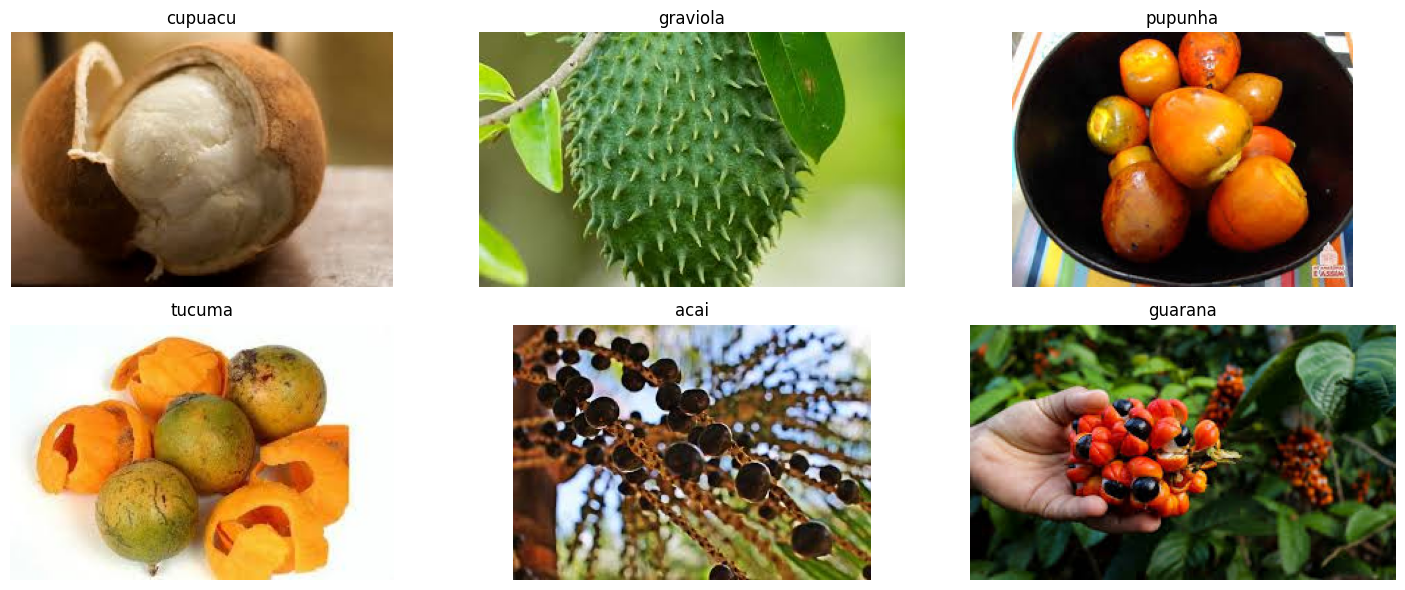

In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# Path to your dataset
train_dir = "/content/drive/MyDrive/Ai and machine learning/Week 5/FruitinAmazon/train"  # change this

# Step 1: Get class directories
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

images = []
titles = []

# Step 2: Select one random image from each class
for cls in classes:
    class_path = os.path.join(train_dir, cls)

    # Get all image files (filter common formats)
    img_files = [f for f in os.listdir(class_path)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if img_files:
        img_name = random.choice(img_files)
        img_path = os.path.join(class_path, img_name)

        img = Image.open(img_path)
        images.append(img)
        titles.append(cls)

# Step 3: Plot images in grid (2 rows)
num_images = len(images)
cols = (num_images + 1) // 2  # divide into 2 rows

plt.figure(figsize=(15, 6))

for i in range(num_images):
    plt.subplot(2, cols, i + 1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:


corrupted_images = []

# Iterate through each class subdirectory
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            # Try opening and verifying the image
            with Image.open(img_path) as img:
                img.verify()  # checks for corruption

        except (IOError, SyntaxError):
            corrupted_images.append(img_path)

            # Remove corrupted image
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

# Final report
if not corrupted_images:
    print("No Corrupted Images Found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


In [ ]:
import tensorflow as tf
# Define image size and batch size
img_height = 128 # Example image height
img_width = 128 # Example image width
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation
# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]
# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
train_dir,
labels='inferred',
label_mode='int',
image_size=(img_height, img_width),
interpolation='nearest',
batch_size=batch_size,
shuffle=True,
validation_split=validation_split,
subset='training',
seed=123
)
# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
train_dir,
labels='inferred',
label_mode='int',
image_size=(img_height, img_width),
interpolation='nearest',
batch_size=batch_size,
shuffle=False,
validation_split=validation_split,
subset='validation',
seed=123
)
# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Set number of classes
num_classes = 6   # Corrected based on your dataset

# Input shape (change based on your dataset)
input_shape = (128, 128, 3)

model = models.Sequential()

# 🔹 Convolutional Layer 1
model.add(layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    strides=1,
    padding='same',
    activation='relu',
    input_shape=input_shape
))

# 🔹 Pooling Layer 1
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=2))

# 🔹 Convolutional Layer 2
model.add(layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    strides=1,
    padding='same',
    activation='relu'
))

# 🔹 Pooling Layer 2
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=2))

# 🔹 Flatten
model.add(layers.Flatten())

# 🔹 Fully Connected Layers
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(128, activation='relu'))

# 🔹 Output Layer
model.add(layers.Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Corrected loss function
    metrics=['accuracy']
)

# Model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping],
    batch_size=16
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.1904 - loss: 2.0751
Epoch 1: val_accuracy improved from None to 0.83333, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 663ms/step - accuracy: 0.1806 - loss: 2.1949 - val_accuracy: 0.8333 - val_loss: 1.3041
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.2488 - loss: 1.7536
Epoch 2: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 513ms/step - accuracy: 0.2778 - loss: 1.7506 - val_accuracy: 0.3889 - val_loss: 1.5572
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.3698 - loss: 1.5392
Epoch 3: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 460ms/step - accuracy: 0.3750 - loss: 1.5055 - val_accuracy: 0.7222 - val_loss: 1.3279
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.5694 - loss: 1.3055
Epoch 4: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 443ms/step - accuracy: 0.5833 - loss: 1.2803 - val_accuracy: 0.3889 - val_loss: 1.4262
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.5237 - loss: 1.127


Epoch 11: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 568ms/step - accuracy: 0.9722 - loss: 0.2545 - val_accuracy: 0.8889 - val_loss: 0.4332
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 1.0000 - loss: 0.1623
Epoch 12: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 441ms/step - accuracy: 1.0000 - loss: 0.1530 - val_accuracy: 0.8333 - val_loss: 0.7349
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.9803 - loss: 0.1721
Epoch 13: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 534ms/step - accuracy: 0.9722 - loss: 0.1660 - val_accuracy: 0.7222 - val_loss: 0.7833
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.9902 - loss: 0.0655
Epoch 14: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 765ms/step - accuracy: 0.9861 - loss: 0.0634 - val_accuracy: 0.7778 - val_loss: 0.5723
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 1.0000 - los


Epoch 16: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 499ms/step - accuracy: 1.0000 - loss: 0.0306 - val_accuracy: 0.9444 - val_loss: 0.2820
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 1.0000 - loss: 0.0279
Epoch 17: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 458ms/step - accuracy: 1.0000 - loss: 0.0270 - val_accuracy: 0.9444 - val_loss: 0.3355
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 1.0000 - loss: 0.0073
Epoch 18: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 443ms/step - accuracy: 1.0000 - loss: 0.0076 - val_accuracy: 0.8889 - val_loss: 0.4136
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 1.0000 - loss: 0.0056
Epoch 19: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 449ms/step - accuracy: 1.0000 - loss: 0.0068 - val_accuracy: 0.7778 - val_loss: 0.5979
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 1.0000 - los

In [ ]:
test_loss, test_acc = model.evaluate(val_ds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.9444 - loss: 0.2820

Test Loss: 0.2820
Test Accuracy: 0.9444


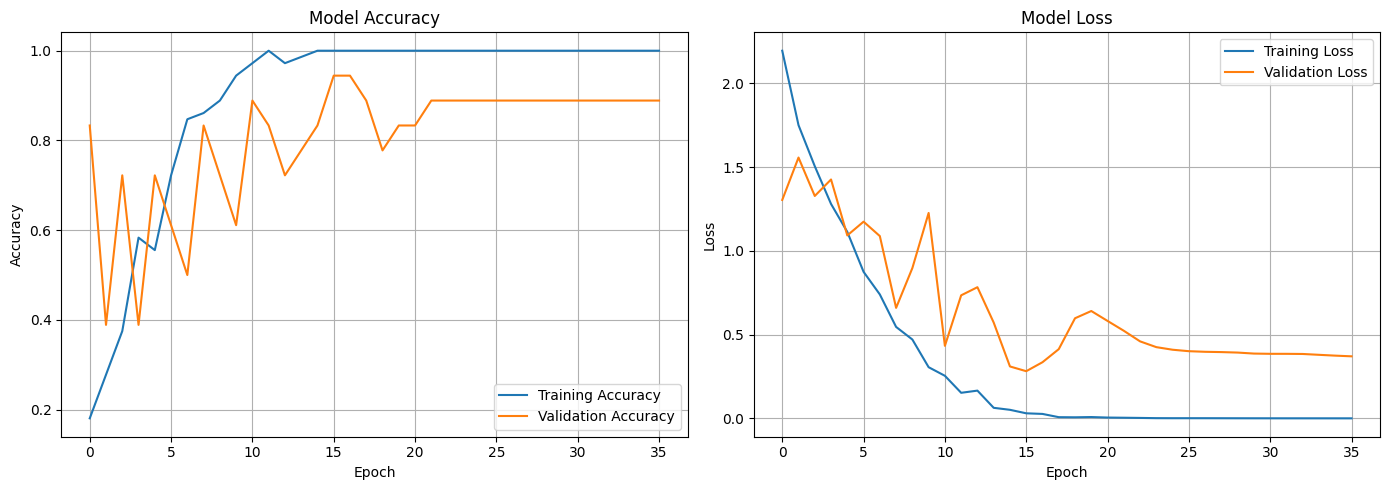

In [ ]:
# Plot training history
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Task 6: Save and Load the Model
# Write your code here

# Save the model
model.save('fruit_classifier_cnn.h5')
print("Model saved to 'fruit_classifier_cnn.h5'")

# Load the saved model
loaded_model = tf.keras.models.load_model('fruit_classifier_cnn.h5')
print("Model loaded successfully.")

# Re-evaluate the loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(val_ds)
print(f"\nLoaded Model - Test Loss: {loaded_loss:.4f}")
print(f"Loaded Model - Test Accuracy: {loaded_acc:.4f}")

Model saved to 'fruit_classifier_cnn.h5'
Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step - accuracy: 0.9444 - loss: 0.2820

Loaded Model - Test Loss: 0.2820
Loaded Model - Test Accuracy: 0.9444


In [ ]:
import tensorflow as tf

test_dir = "/content/drive/MyDrive/Ai and machine learning/Week 5/FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128, 128),
    batch_size=16,
    shuffle=False   # VERY IMPORTANT for correct evaluation
)

Found 30 files belonging to 6 classes.


In [ ]:
test_ds = test_ds.map(lambda x, y: (x / 255.0, y))

In [ ]:
import numpy as np

# Get predictions (probabilities)
predictions = model.predict(test_ds)

# Convert probabilities → class labels
pred_labels = np.argmax(predictions, axis=1)

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step


In [ ]:
true_labels = []

for images, labels in test_ds:
    true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)

In [ ]:
from sklearn.metrics import classification_report

class_names = classes # Use the 'classes' variable that was already extracted

print(classification_report(true_labels, pred_labels, target_names=class_names))

              precision    recall  f1-score   support

     cupuacu       0.80      0.80      0.80         5
    graviola       1.00      0.20      0.33         5
     pupunha       0.44      0.80      0.57         5
      tucuma       0.80      0.80      0.80         5
        acai       1.00      0.20      0.33         5
     guarana       0.33      0.60      0.43         5

    accuracy                           0.57        30
   macro avg       0.73      0.57      0.54        30
weighted avg       0.73      0.57      0.54        30

